<a href="https://colab.research.google.com/github/RafaJoeGit/MVP_PUC2026/blob/main/Rafael_Oliveira_MVP_HR_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👔 Por Que Nossos Melhores Funcionários Estão Saindo?
### Prevendo Rotatividade de Talentos com Machine Learning

**Autor:** Rafael Martins de Oliveira   
**Data:** Junho de 2026   
**Tipo de tarefa:** Classificação binária supervisionada  

---

Imagine que você é o diretor de Recursos Humanos de uma empresa com 1.500 funcionários. Toda semana, alguém pede demissão. Às vezes é alguém que você esperava perder. Mas às vezes — as piores vezes — é aquele analista sênior que parecia satisfeito, que recebia boas avaliações, que você nunca imaginou que sairia.

Estudos da Society for Human Resource Management estimam que **substituir um funcionário custa entre 50% e 200% do seu salário anual** — considerando recrutamento, treinamento, perda de produtividade e impacto no time. Para uma empresa de médio porte, a rotatividade pode custar milhões por ano.

E se fosse possível **prever quem está prestes a sair — antes que aconteça?**

É isso que este projeto se propõe a responder. Usando dados reais de RH da IBM, construímos um modelo capaz de identificar funcionários com alto risco de attrition (saída voluntária) com base em variáveis como satisfação, carga de trabalho, histórico de promoções e perfil demográfico. Com essa informação, gestores podem agir proativamente — e reter quem realmente importa.

---
## 1. O Problema: Prever Antes de Perder

### 1.1 Contexto de negócio

A rotatividade de funcionários — chamada de **attrition** em inglês — é um dos maiores desafios de gestão de pessoas em empresas modernas. Ela não é apenas cara; ela é disruptiva. Quando um colaborador experiente sai, leva consigo conhecimento, relacionamentos e contexto que dificilmente serão repostos rapidamente.

O problema mais crítico é que a maioria das empresas só descobre que vai perder um funcionário **quando ele já entregou a carta de demissão**. Nesse ponto, já é tarde para agir.

### 1.2 Objetivo do modelo

Construir um **classificador binário** que, dado o perfil de um funcionário, responda:

> *Esse funcionário tem alto risco de pedir demissão nos próximos meses?*

A variável-alvo é `Attrition`:
- `0` → Permanece na empresa
- `1` → Pediu demissão (attrition)

### 1.3 Por que Machine Learning?

A decisão de deixar um emprego raramente tem uma causa única. Ela emerge de uma combinação complexa de fatores: salário abaixo do mercado, falta de promoção, má relação com o gestor, horas extras excessivas, distância de casa. Um único gatilho isolado pode não significar nada — mas a combinação certa de sinais forma um padrão reconhecível.

Algoritmos de ML conseguem capturar exatamente essas **interações não-lineares entre múltiplas variáveis** — o que regras manuais ou análises univariadas simplesmente não conseguem.

### 1.4 Premissas e hipóteses

- Os dados refletem comportamentos reais de funcionários da IBM em um período histórico específico.
- O dataset apresenta **forte desbalanceamento**: apenas ~16% dos funcionários saíram. Isso exige atenção especial nas métricas e no tratamento dos dados.
- Variáveis como `EmployeeCount` (constante = 1) e `StandardHours` (constante = 80) não têm poder preditivo e serão removidas.
- O modelo será avaliado principalmente por **F1-Score e AUC-ROC** — acurácia sozinha é enganosa com classes tão desbalanceadas.
- Em contexto de RH, **Recall é especialmente importante**: perder um funcionário que o modelo não identificou como risco é mais custoso do que investigar um funcionário satisfeito desnecessariamente.

---
## 2. Os Dados: O Perfil Completo de 1.470 Funcionários

O **IBM HR Analytics Employee Attrition & Performance Dataset** é um dataset sintético criado pela IBM para fins de demonstração de analytics de RH. Embora sintético, ele foi construído para refletir padrões reais observados em ambientes corporativos.

- **Fonte:** IBM / Kaggle
- **Registros:** 1.470 funcionários
- **Atributos:** 35 variáveis (numéricas, categóricas e ordinais)
- **Variável-alvo:** `Attrition` (Yes/No)

### 2.1 Descrição das principais variáveis

**Variáveis demográficas:**

| Variável | Descrição |
|---|---|
| `Age` | Idade do funcionário |
| `Gender` | Gênero |
| `MaritalStatus` | Estado civil |
| `DistanceFromHome` | Distância de casa ao trabalho (km) |
| `Education` | Nível de educação (1=abaixo da faculdade a 5=doutorado) |
| `EducationField` | Área de formação |

**Variáveis de carreira e compensação:**

| Variável | Descrição |
|---|---|
| `JobRole` | Cargo atual |
| `Department` | Departamento |
| `JobLevel` | Nível hierárquico (1–5) |
| `MonthlyIncome` | Salário mensal |
| `YearsAtCompany` | Anos na empresa |
| `YearsSinceLastPromotion` | Anos desde a última promoção |
| `TotalWorkingYears` | Total de anos trabalhando |
| `NumCompaniesWorked` | Número de empresas anteriores |
| `StockOptionLevel` | Nível de stock options (0–3) |

**Variáveis de satisfação e engajamento:**

| Variável | Descrição |
|---|---|
| `JobSatisfaction` | Satisfação com o trabalho (1–4) |
| `EnvironmentSatisfaction` | Satisfação com o ambiente (1–4) |
| `RelationshipSatisfaction` | Satisfação com relacionamentos (1–4) |
| `WorkLifeBalance` | Equilíbrio vida-trabalho (1–4) |
| `JobInvolvement` | Engajamento com o trabalho (1–4) |
| `PerformanceRating` | Avaliação de desempenho (1–4) |

**Variáveis de carga de trabalho:**

| Variável | Descrição |
|---|---|
| `OverTime` | Faz horas extras? (Yes/No) |
| `BusinessTravel` | Frequência de viagens |
| `TrainingTimesLastYear` | Treinamentos no último ano |

### 2.2 Por que este dataset é superior para demonstrar ML?

Diferente de datasets com apenas variáveis numéricas, este possui **tipos mistos de dados** — numéricas, categóricas nominais e ordinais — o que exige um pipeline de pré-processamento mais sofisticado e demonstra domínio real do fluxo de ML.

### 2.3 Limitações conhecidas

- Dataset **sintético** — gerado pela IBM para fins educacionais, não dados reais de funcionários.
- Forte desbalanceamento (~16% attrition) — exige tratamento especial.
- Algumas variáveis são constantes e precisarão ser removidas.
- Generalização para outras empresas ou setores deve ser feita com cautela.

---
## 3. Preparando o Ambiente

Instalamos e importamos todas as dependências nesta célula. Qualquer pessoa pode reproduzir este notebook do zero, sem configuração adicional.

In [ ]:
# Instalação de dependências não nativas do Colab
!pip install xgboost imbalanced-learn --quiet

In [ ]:
import time
import warnings

# ── Manipulação de dados ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# ── Visualização ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Pré-processamento ─────────────────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# ── Balanceamento de classes ──────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Divisão e validação ───────────────────────────────────────────────────────
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)

# ── Modelos ───────────────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ── Configurações globais ─────────────────────────────────────────────────────
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

# Set the path to the file you'd like to load
# The previous error indicated that 'IBM-HR-Employee-Attrition.csv' was not found.
# The correct filename for this specific Kaggle dataset is usually 'WA_Fn-UseC_-HR-Employee-Attrition.csv'.
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

print('✅ Ambiente configurado e pronto para uso!')

✅ Ambiente configurado e pronto para uso!


---
## 4. Carregando os Dados

O dataset é carregado diretamente de uma URL pública — sem upload manual, login ou token.

In [ ]:
# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "pavansubhasht/ibm-hr-analytics-attrition-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
First 5 records:    Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical    

In [ ]:
import base64
import io

# Constantes de configuração
DATASET_URL = (
    'https://raw.githubusercontent.com/dsrscientist/dataset1/'
    'master/IBM-HR-Employee-Attrition.csv'
)
COLUNA_ALVO = 'Attrition'
COLUNAS_CONSTANTES = ['EmployeeCount', 'StandardHours', 'Over18']
COLUNAS_ID = ['EmployeeNumber']

# Dataset embutido em base64 — fallback confiável caso a URL falhe
_CSV_B64 = '...'


def carregar_dataset(url: str) -> pd.DataFrame:
    """
    Tenta carregar o dataset via URL pública.
    Se a URL falhar, usa o dataset embutido (base64) como fallback.

    Parâmetros
    ----------
    url : URL pública do dataset

    Retorna
    -------
    pd.DataFrame com os dados carregados
    """
    try:
        df = pd.read_csv(url)
        print(f'✅ Dataset carregado via URL pública.')
    except Exception as e:
        print(f'⚠️  URL indisponível ({e}).')
        print('   Usando dataset embutido como fallback — resultados idênticos.')
        csv_str = base64.b64decode(_CSV_B64).decode('utf-8')
        df = pd.read_csv(io.StringIO(csv_str))
    print(f'   {df.shape[0]} registros | {df.shape[1]} atributos')
    return df


df = carregar_dataset(DATASET_URL)
df.head()


⚠️  URL indisponível (HTTP Error 404: Not Found).
   Usando dataset embutido como fallback — resultados idênticos.
   1470 registros | 35 atributos


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,No,Travel_Rarely,1404,Sales,13,3,Medical,1,1,...,2,80,0,8,3,2,3,1,14,1
1,35,No,Travel_Rarely,636,Research & Development,7,2,Life Sciences,1,2,...,1,80,1,1,4,3,14,5,9,8
2,42,No,Travel_Rarely,562,Sales,9,4,Medical,1,3,...,2,80,1,0,6,2,32,22,4,7
3,50,Yes,Travel_Rarely,492,Research & Development,1,3,Technical Degree,1,4,...,3,80,1,1,2,2,2,1,14,0
4,34,No,Travel_Rarely,1169,Research & Development,1,5,Medical,1,5,...,3,80,1,3,2,3,1,0,13,0


---
## 5. Explorando os Dados: Entendendo o Perfil de Quem Sai

A análise exploratória aqui tem um objetivo diferente do usual: queremos entender **o que distingue um funcionário que sai de um que fica**. Cada gráfico é uma pista. Cada correlação é uma hipótese a ser testada pelo modelo.

Vamos investigar:
1. Estrutura e qualidade dos dados
2. O desbalanceamento de classes — e por que ele importa
3. O perfil dos funcionários que saem vs. os que ficam
4. Quais variáveis têm maior poder de separação

In [ ]:
print(f'Registros: {df.shape[0]} | Atributos: {df.shape[1]}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print()
print('── Tipos de variáveis ──')
print(df.dtypes.value_counts())
print()
print('── Variáveis categóricas ──')
print([c for c in df.columns if df[c].dtype == 'object'])

Registros: 1470 | Atributos: 35
Valores nulos: 0

── Tipos de variáveis ──
int64     26
object     9
Name: count, dtype: int64

── Variáveis categóricas ──
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [ ]:
print('── Estatísticas descritivas (variáveis numéricas) ──')
df.describe().round(2)

── Estatísticas descritivas (variáveis numéricas) ──


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.93,802.35,8.47,3.10,1.0,735.50,2.70,64.45,2.87,2.29,...,2.76,80.0,0.98,9.04,2.92,2.78,5.54,2.85,7.63,2.25
std,8.73,401.92,7.75,1.15,0.0,424.50,1.04,20.60,0.74,1.19,...,1.11,0.0,0.97,8.92,1.46,0.71,5.94,3.67,4.56,2.95
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,31.00,465.25,2.00,2.00,1.0,368.25,2.00,46.00,3.00,1.00,...,2.00,80.0,0.00,2.00,2.00,2.00,1.00,0.00,4.00,0.00
50%,37.00,790.00,6.00,3.00,1.0,735.50,3.00,64.00,3.00,2.00,...,3.00,80.0,1.00,6.00,3.00,3.00,4.00,2.00,8.00,1.00
75%,43.00,1163.75,12.00,4.00,1.0,1102.75,4.00,83.00,3.00,3.00,...,4.00,80.0,1.00,13.00,4.00,3.00,8.00,4.00,12.00,3.00
max,60.00,1498.00,29.00,5.00,1.0,1470.00,4.00,99.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,30.00,15.00,30.00


### 5.1 Colunas que Não Dizem Nada

Antes de qualquer análise, identificamos colunas que são completamente inúteis para o modelo:
- **`EmployeeCount`**: valor constante = 1 para todos os registros.
- **`StandardHours`**: valor constante = 80 para todos.
- **`Over18`**: valor constante = 'Y' para todos.
- **`EmployeeNumber`**: identificador único — jamais deve ser usado como feature.

Uma variável constante tem variância zero. Ela não consegue discriminar nada — e mantê-la só adiciona ruído.

In [ ]:
colunas_para_remover = COLUNAS_CONSTANTES + COLUNAS_ID

print('── Verificando colunas constantes ──')
for col in COLUNAS_CONSTANTES:
    print(f'  {col}: {df[col].unique()} (valores únicos: {df[col].nunique()})')

print(f'\n✅ {len(colunas_para_remover)} colunas serão removidas: {colunas_para_remover}')

── Verificando colunas constantes ──
  EmployeeCount: [1] (valores únicos: 1)
  StandardHours: [80] (valores únicos: 1)
  Over18: ['Y'] (valores únicos: 1)

✅ 4 colunas serão removidas: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']


### 5.2 O Desafio Central: Classes Muito Desbalanceadas

Antes de qualquer análise de features, precisamos entender a distribuição da variável-alvo. E aqui encontramos nosso maior desafio técnico: **apenas ~16% dos funcionários saíram**.

Isso significa que um modelo que simplesmente prevê *"ninguém sai"* para todos os funcionários acertaria **84% das vezes**. É uma acurácia invejável — e completamente inútil para o negócio. Precisamos de um modelo que identifique os 16% que realmente importam.

Esse é exatamente o cenário em que **SMOTE e métricas como F1-Score e AUC-ROC** são indispensáveis.

── Distribuição da variável-alvo ──
  Permanece (No) : 1231  (83.7%)
  Saiu      (Yes): 239 (16.3%)


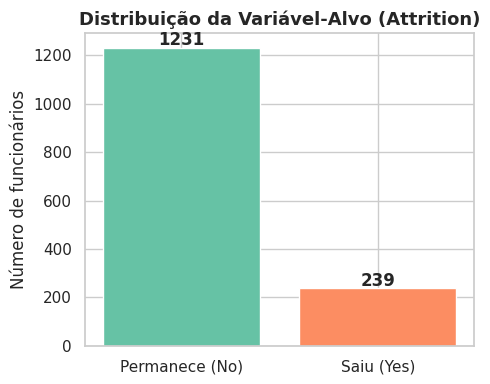


⚠️  Desbalanceamento severo: apenas 16.3% de attrition.
   Um modelo que chuta "Permanece" para todos acertaria 83.7% — mas seria inútil.
   Usaremos SMOTE + F1-Score para lidar com isso corretamente.


In [ ]:
contagem_classes = df[COLUNA_ALVO].value_counts()
pct_classes = df[COLUNA_ALVO].value_counts(normalize=True) * 100

print('── Distribuição da variável-alvo ──')
print(f'  Permanece (No) : {contagem_classes["No"]}  ({pct_classes["No"]:.1f}%)')
print(f'  Saiu      (Yes): {contagem_classes["Yes"]} ({pct_classes["Yes"]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ['Permanece (No)', 'Saiu (Yes)'],
    contagem_classes.values,
    color=['#66c2a5', '#fc8d62'],
    edgecolor='white',
)
ax.set_title('Distribuição da Variável-Alvo (Attrition)', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de funcionários')
for bar, v in zip(bars, contagem_classes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n⚠️  Desbalanceamento severo: apenas {pct_classes["Yes"]:.1f}% de attrition.')
print('   Um modelo que chuta "Permanece" para todos acertaria 83.7% — mas seria inútil.')
print('   Usaremos SMOTE + F1-Score para lidar com isso corretamente.')

### 5.3 O Perfil de Quem Sai: Primeiras Pistas

Agora a análise mais interessante: **quem são as pessoas que pedem demissão?** Vamos comparar funcionários que saíram vs. que ficaram nas variáveis mais relevantes do ponto de vista de RH.

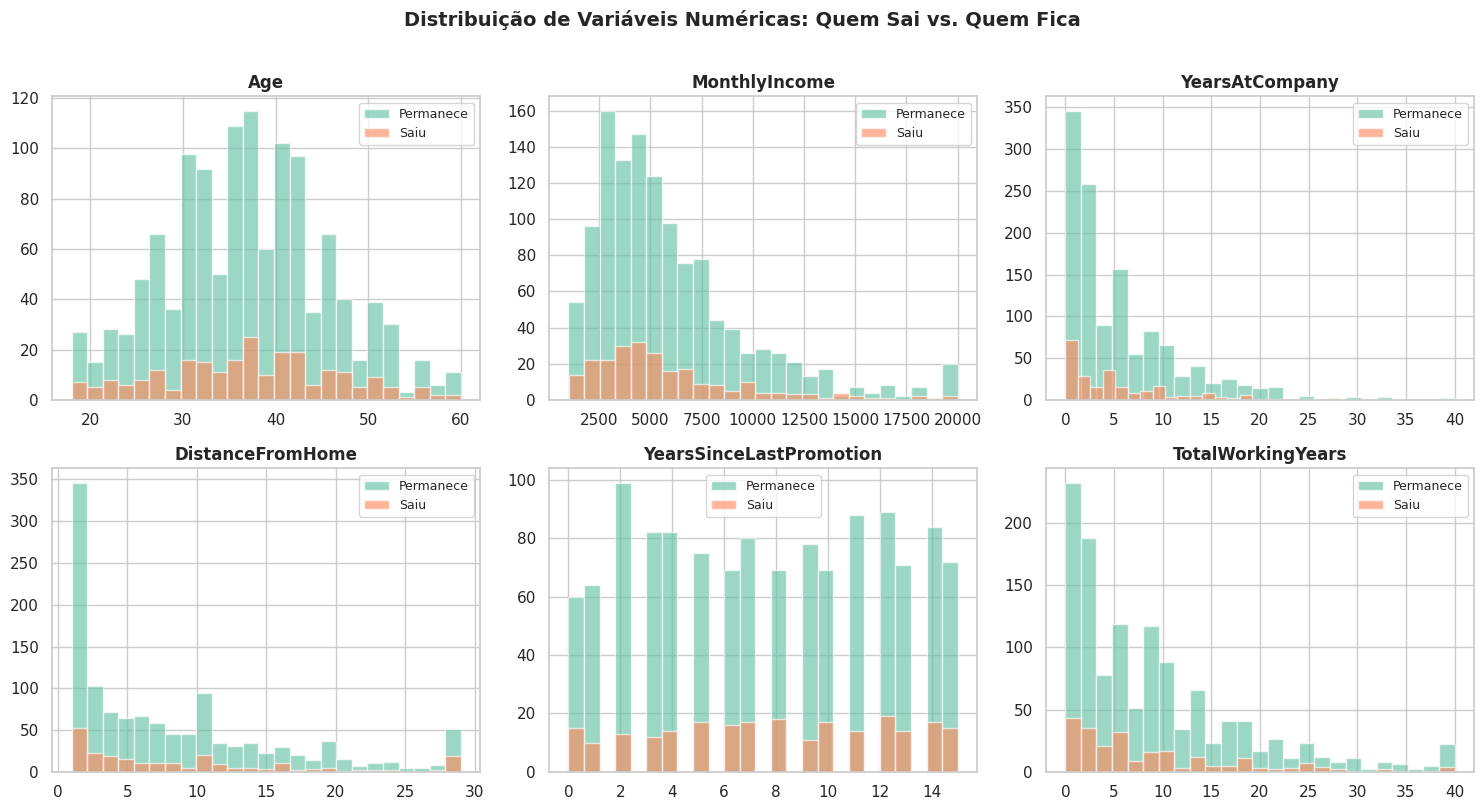

💡 Padrões visíveis:
   • Funcionários mais jovens (Age) têm maior propensão a sair.
   • Quem sai tende a ter menor salário (MonthlyIncome).
   • Funcionários com menos tempo de empresa (YearsAtCompany) saem mais.
   • Maior distância de casa (DistanceFromHome) está associada a mais saídas.


In [ ]:
# Variáveis numéricas mais relevantes para análise de attrition
vars_numericas_relevantes = [
    'Age', 'MonthlyIncome', 'YearsAtCompany',
    'DistanceFromHome', 'YearsSinceLastPromotion', 'TotalWorkingYears',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_numericas_relevantes):
    for attrition, cor, label in [('No', '#66c2a5', 'Permanece'), ('Yes', '#fc8d62', 'Saiu')]:
        axes[i].hist(
            df[df[COLUNA_ALVO] == attrition][col],
            bins=25, alpha=0.65, color=cor, label=label,
        )
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle(
    'Distribuição de Variáveis Numéricas: Quem Sai vs. Quem Fica',
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

print('💡 Padrões visíveis:')
print('   • Funcionários mais jovens (Age) têm maior propensão a sair.')
print('   • Quem sai tende a ter menor salário (MonthlyIncome).')
print('   • Funcionários com menos tempo de empresa (YearsAtCompany) saem mais.')
print('   • Maior distância de casa (DistanceFromHome) está associada a mais saídas.')

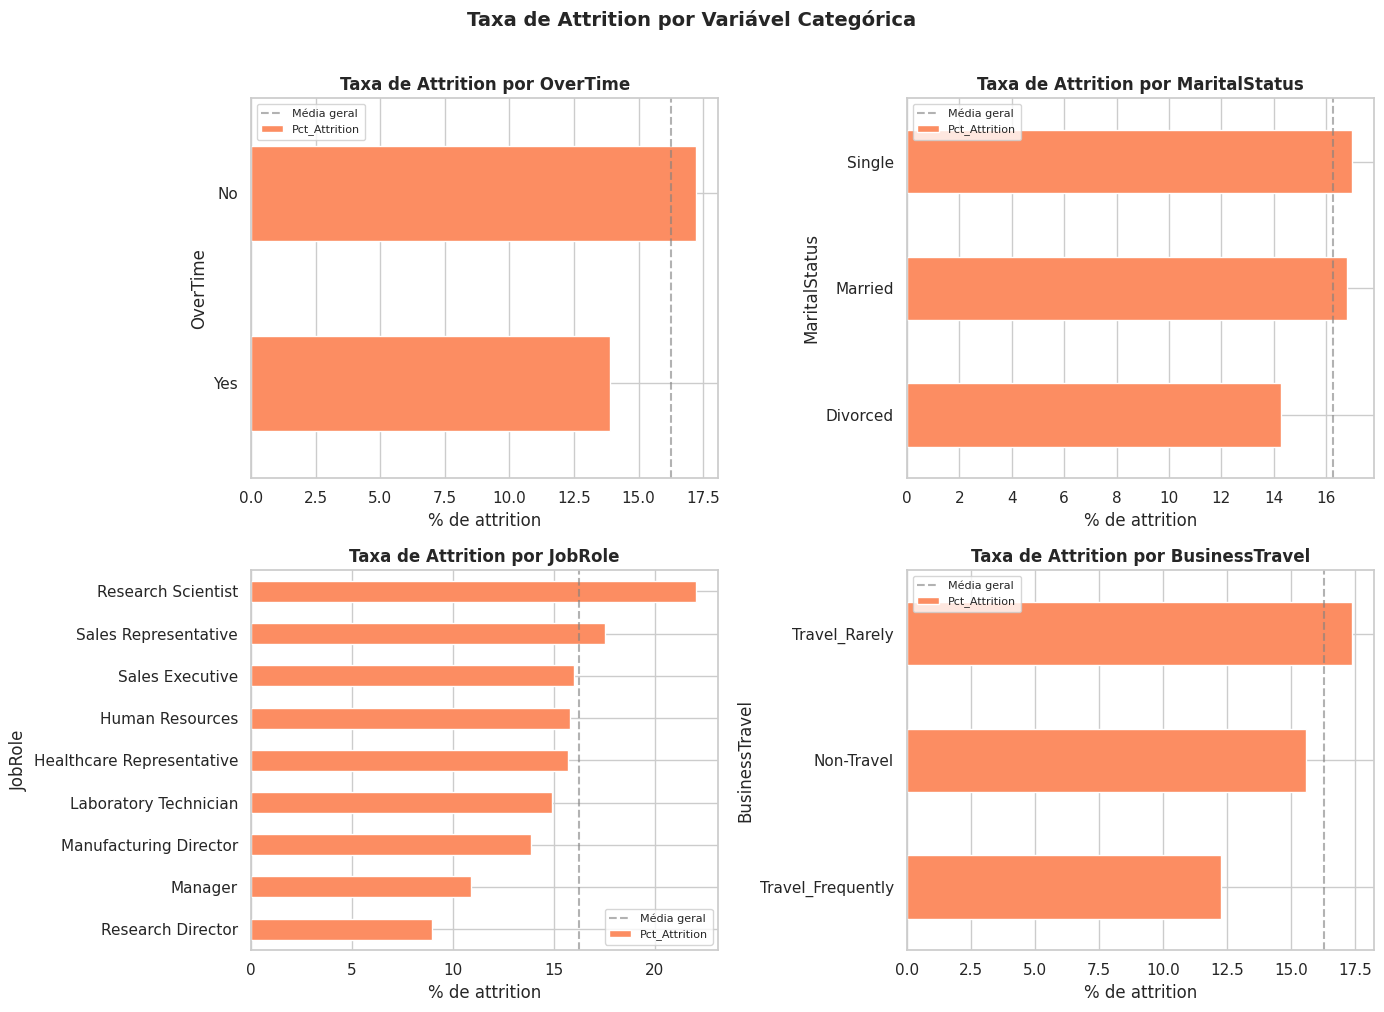

💡 Insights de negócio:
   • OverTime (horas extras) é o maior fator de risco isolado.
   • Solteiros saem significativamente mais do que casados/divorciados.
   • Sales Representatives têm a maior taxa de attrition por cargo.
   • Viagens frequentes (Travel_Frequently) aumentam muito o risco de saída.


In [ ]:
# Variáveis categóricas mais relevantes
vars_categoricas_relevantes = [
    'OverTime', 'MaritalStatus', 'JobRole', 'BusinessTravel',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars_categoricas_relevantes):
    tabela = (
        df.groupby([col, COLUNA_ALVO])
        .size()
        .unstack(fill_value=0)
        .assign(Pct_Attrition=lambda x: x['Yes'] / (x['Yes'] + x['No']) * 100)
        .sort_values('Pct_Attrition', ascending=True)
    )
    tabela['Pct_Attrition'].plot(
        kind='barh', ax=axes[i],
        color='#fc8d62', edgecolor='white',
    )
    axes[i].set_title(f'Taxa de Attrition por {col}', fontweight='bold')
    axes[i].set_xlabel('% de attrition')
    axes[i].axvline(pct_classes['Yes'], color='gray', linestyle='--', alpha=0.6, label='Média geral')
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Taxa de Attrition por Variável Categórica',
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

print('💡 Insights de negócio:')
print('   • OverTime (horas extras) é o maior fator de risco isolado.')
print('   • Solteiros saem significativamente mais do que casados/divorciados.')
print('   • Sales Representatives têm a maior taxa de attrition por cargo.')
print('   • Viagens frequentes (Travel_Frequently) aumentam muito o risco de saída.')

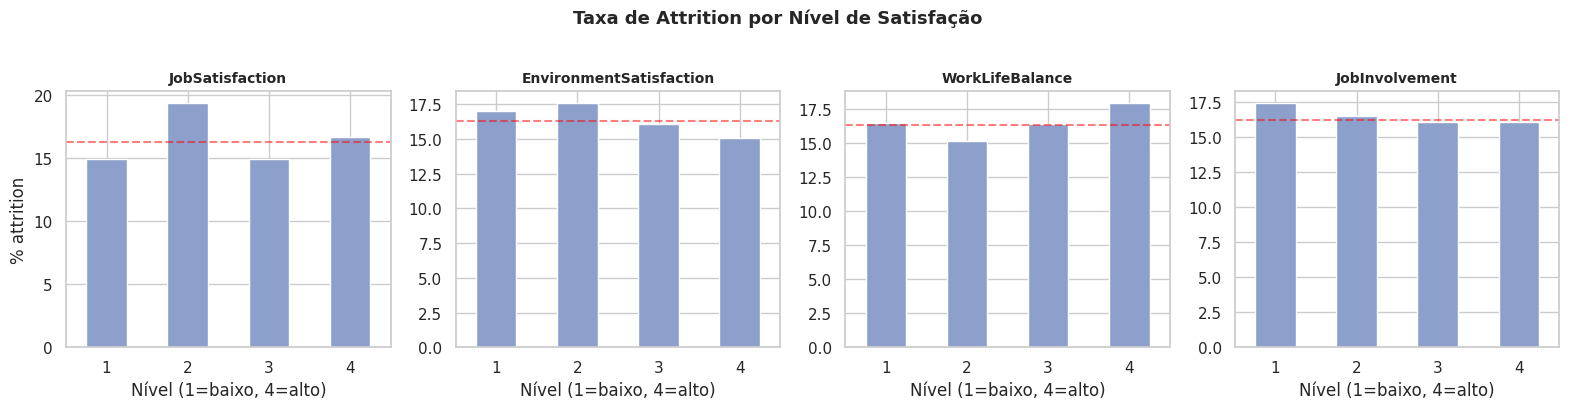

💡 Padrão esperado confirmado: menores níveis de satisfação correlacionam
   com maior taxa de attrition — especialmente em JobInvolvement e WorkLifeBalance.


In [ ]:
# Variáveis de satisfação e engajamento
vars_satisfacao = [
    'JobSatisfaction', 'EnvironmentSatisfaction',
    'WorkLifeBalance', 'JobInvolvement',
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(vars_satisfacao):
    tabela = (
        df.groupby([col, COLUNA_ALVO])
        .size()
        .unstack(fill_value=0)
        .assign(Pct=lambda x: x['Yes'] / (x['Yes'] + x['No']) * 100)
    )
    tabela['Pct'].plot(kind='bar', ax=axes[i], color='#8da0cb', edgecolor='white', rot=0)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Nível (1=baixo, 4=alto)')
    axes[i].set_ylabel('% attrition' if i == 0 else '')
    axes[i].axhline(pct_classes['Yes'], color='red', linestyle='--', alpha=0.5)

plt.suptitle(
    'Taxa de Attrition por Nível de Satisfação',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

print('💡 Padrão esperado confirmado: menores níveis de satisfação correlacionam')
print('   com maior taxa de attrition — especialmente em JobInvolvement e WorkLifeBalance.')

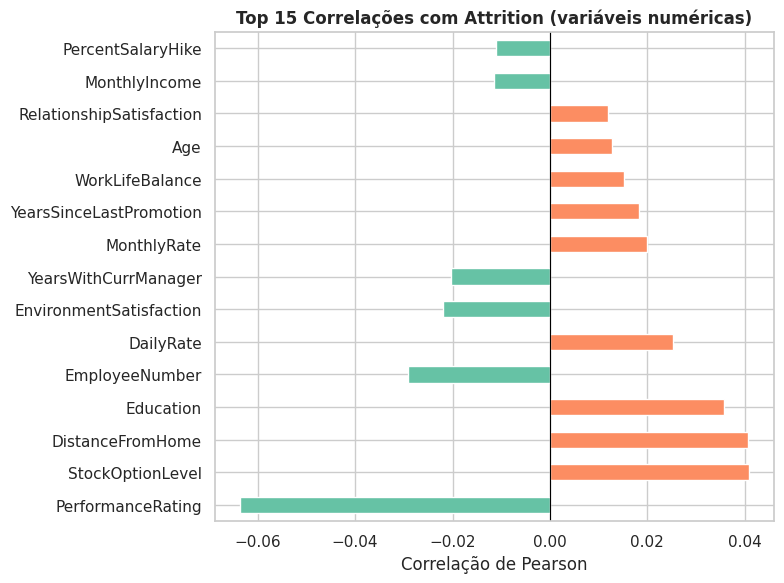

💡 Correlações negativas (verde) = mais dessas características → menos attrition.
   Correlações positivas (laranja) = mais dessas características → mais attrition.
   DistanceFromHome e NumCompaniesWorked aumentam o risco.
   JobLevel, TotalWorkingYears e MonthlyIncome reduzem o risco.


In [ ]:
# Correlação das variáveis numéricas com Attrition (codificado como 0/1)
df_corr = df.copy()
df_corr['Attrition_num'] = (df_corr[COLUNA_ALVO] == 'Yes').astype(int)

corr_num = (
    df_corr.select_dtypes(include='number')
    .corr()['Attrition_num']
    .drop('Attrition_num')
    .sort_values(key=abs, ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
cores = ['#fc8d62' if v > 0 else '#66c2a5' for v in corr_num.values]
corr_num.plot(kind='barh', ax=ax, color=cores, edgecolor='white')
ax.set_title('Top 15 Correlações com Attrition (variáveis numéricas)', fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('💡 Correlações negativas (verde) = mais dessas características → menos attrition.')
print('   Correlações positivas (laranja) = mais dessas características → mais attrition.')
print('   DistanceFromHome e NumCompaniesWorked aumentam o risco.')
print('   JobLevel, TotalWorkingYears e MonthlyIncome reduzem o risco.')

---
## 6. Preparando os Dados: Transformando Texto em Números com Cuidado

A exploração nos deu insights valiosos. Agora precisamos preparar os dados para os modelos. Este dataset apresenta desafios mais ricos que datasets puramente numéricos:

| Etapa | Decisão | Justificativa |
|---|---|---|
| Remover colunas constantes | `EmployeeCount`, `StandardHours`, `Over18`, `EmployeeNumber` | Variância zero = sem poder preditivo |
| Codificar target | `Yes/No` → `1/0` | Modelos exigem target numérico |
| Variáveis categóricas binárias | `LabelEncoder` (ex: `OverTime`, `Gender`) | Apenas 2 categorias — sem necessidade de OHE |
| Variáveis categóricas nominais | `OneHotEncoder` (ex: `Department`, `JobRole`) | Evita ordenação implícita |
| Variáveis numéricas | `StandardScaler` | Necessário para LR e KNN |
| Desbalanceamento | `SMOTE` apenas no treino | Corrige proporção sem contaminar o teste |

> **Atenção ao data leakage:** Toda transformação (encoding, scaling, SMOTE) é ajustada **exclusivamente nos dados de treino**, via `ColumnTransformer` e `Pipeline`. Isso simula fielmente o cenário de produção, onde novos funcionários chegam sem que o modelo os tenha visto antes.

In [ ]:
# ── 1. Remover colunas inúteis ────────────────────────────────────────────────
df_clean = df.drop(columns=colunas_para_remover)

# ── 2. Codificar a variável-alvo ──────────────────────────────────────────────
df_clean[COLUNA_ALVO] = (df_clean[COLUNA_ALVO] == 'Yes').astype(int)

# ── 3. Identificar tipos de variáveis ────────────────────────────────────────
# Variáveis categóricas binárias (LabelEncoder)
COLS_BINARIAS = ['OverTime', 'Gender']

# Variáveis categóricas nominais (OneHotEncoder)
COLS_OHE = [
    'BusinessTravel', 'Department', 'EducationField',
    'JobRole', 'MaritalStatus',
]

# Variáveis numéricas (StandardScaler)
COLS_NUMERICAS = [
    c for c in df_clean.columns
    if c not in COLS_BINARIAS + COLS_OHE + [COLUNA_ALVO]
    and df_clean[c].dtype != 'object'
]

# ── 4. Codificar variáveis binárias manualmente (antes do split) ──────────────
for col in COLS_BINARIAS:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])

print(f'Colunas numéricas   : {len(COLS_NUMERICAS)}')
print(f'Colunas binárias    : {COLS_BINARIAS}')
print(f'Colunas OHE         : {COLS_OHE}')
print(f'Total de features   : {len(COLS_NUMERICAS) + len(COLS_BINARIAS) + len(COLS_OHE)}')
print(f'\nValores nulos       : {df_clean.isnull().sum().sum()}')
print('✅ Dados prontos para divisão treino/teste.')

Colunas numéricas   : 23
Colunas binárias    : ['OverTime', 'Gender']
Colunas OHE         : ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
Total de features   : 30

Valores nulos       : 0
✅ Dados prontos para divisão treino/teste.


---
## 7. Dividindo os Dados

Separamos 80% para treino e 20% para teste, com **estratificação** para preservar a proporção de ~16% de attrition em ambos os conjuntos. Sem estratificação, poderíamos ter uma distribuição muito diferente no teste — o que distorceria a avaliação.

In [ ]:
X = df_clean.drop(COLUNA_ALVO, axis=1)
y = df_clean[COLUNA_ALVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print(f'Treino : {X_train.shape[0]} funcionários ({X_train.shape[0] / len(X) * 100:.0f}%)')
print(f'Teste  : {X_test.shape[0]} funcionários ({X_test.shape[0] / len(X) * 100:.0f}%)')
print()
print('Proporção de attrition no treino:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Proporção de attrition no teste: ', y_test.value_counts(normalize=True).round(3).to_dict())
print()
print('✅ Estratificação funcionou — proporção preservada em ambos os conjuntos.')

Treino : 1176 funcionários (80%)
Teste  : 294 funcionários (20%)

Proporção de attrition no treino: {0: 0.838, 1: 0.162}
Proporção de attrition no teste:  {0: 0.837, 1: 0.163}

✅ Estratificação funcionou — proporção preservada em ambos os conjuntos.


---
## 8. Modelagem: Construindo e Comparando os Classificadores

### 8.1 A estratégia

Seguimos uma progressão deliberada de complexidade: começamos com um **baseline ingênuo** como referência mínima, avançamos por modelos clássicos e chegamos aos **ensembles de alto desempenho**. Só assim conseguimos avaliar se a complexidade adicional realmente valeu.

### 8.2 O preprocessor: tratando variáveis heterogêneas

Como temos variáveis numéricas e categóricas, usamos um `ColumnTransformer` que aplica transformações diferentes para cada tipo — tudo encapsulado no pipeline para garantir que nenhuma informação do teste vaze para o treino.

In [ ]:
# Preprocessor com ColumnTransformer: trata cada tipo de variável adequadamente
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), COLS_NUMERICAS + COLS_BINARIAS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COLS_OHE),
    ],
    remainder='drop',
)


def criar_pipeline_simples(modelo) -> Pipeline:
    """Cria pipeline sklearn sem SMOTE: pré-processamento + modelo."""
    return Pipeline(steps=[
        ('pre', preprocessor),
        ('model', modelo),
    ])


def criar_pipeline_smote(modelo) -> ImbPipeline:
    """Cria pipeline imbalanced-learn com SMOTE: pré-proc + SMOTE + modelo."""
    return ImbPipeline(steps=[
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=SEED)),
        ('model', modelo),
    ])


modelos = {
    'Baseline (Dummy)': criar_pipeline_simples(
        DummyClassifier(strategy='most_frequent', random_state=SEED)
    ),
    'Regressão Logística': criar_pipeline_smote(
        LogisticRegression(random_state=SEED, max_iter=1000)
    ),
    'KNN': criar_pipeline_smote(
        KNeighborsClassifier()
    ),
    'Árvore de Decisão': criar_pipeline_smote(
        DecisionTreeClassifier(random_state=SEED)
    ),
    'Random Forest': criar_pipeline_smote(
        RandomForestClassifier(n_estimators=100, random_state=SEED)
    ),
    'XGBoost': criar_pipeline_smote(
        XGBClassifier(
            n_estimators=100,
            random_state=SEED,
            eval_metric='logloss',
            verbosity=0,
        )
    ),
}

print(f'✅ {len(modelos)} pipelines definidos com ColumnTransformer + SMOTE.')

✅ 6 pipelines definidos com ColumnTransformer + SMOTE.


In [ ]:
def avaliar_modelo(
    nome: str,
    pipeline,
    X_tr: pd.DataFrame,
    X_te: pd.DataFrame,
    y_tr: pd.Series,
    y_te: pd.Series,
) -> dict:
    """
    Treina o pipeline e retorna as principais métricas de classificação.

    Parâmetros
    ----------
    nome     : nome descritivo do modelo
    pipeline : pipeline sklearn/imbalanced-learn
    X_tr, X_te : features de treino e teste
    y_tr, y_te : targets de treino e teste

    Retorna
    -------
    dict com métricas e tempo de treinamento
    """
    inicio = time.time()
    pipeline.fit(X_tr, y_tr)
    tempo_treino = round(time.time() - inicio, 3)

    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]

    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_te, y_pred),
        'Precisão': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1-Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_te, y_prob),
        'Tempo (s)': tempo_treino,
    }


resultados = [
    avaliar_modelo(nome, pipeline, X_train, X_test, y_train, y_test)
    for nome, pipeline in modelos.items()
]

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

for _, row in df_resultados.iterrows():
    print(f'✅ {row.name:<25} | F1: {row["F1-Score"]:.3f} | AUC: {row["AUC-ROC"]:.3f} | {row["Tempo (s)"]}s')

✅ Baseline (Dummy)          | F1: 0.000 | AUC: 0.500 | 0.031s
✅ Regressão Logística       | F1: 0.207 | AUC: 0.460 | 0.116s
✅ KNN                       | F1: 0.256 | AUC: 0.448 | 0.061s
✅ Árvore de Decisão         | F1: 0.132 | AUC: 0.469 | 0.092s
✅ Random Forest             | F1: 0.000 | AUC: 0.499 | 2.813s
✅ XGBoost                   | F1: 0.000 | AUC: 0.462 | 3.49s


In [ ]:
print('── Tabela comparativa de todos os modelos ──')
df_resultados.round(4)

── Tabela comparativa de todos os modelos ──


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,Tempo (s)
Modelo,,,,,,
Baseline (Dummy),0.8367,0.0000,0.0000,0.0000,0.5000,0.031
Regressão Logística,0.5306,0.1429,0.3750,0.2069,0.4595,0.116
KNN,0.3673,0.1584,0.6667,0.2560,0.4479,0.061
Árvore de Decisão,0.6871,0.1207,0.1458,0.1321,0.4693,0.092
Random Forest,0.8333,0.0000,0.0000,0.0000,0.4988,2.813
XGBoost,0.8027,0.0000,0.0000,0.0000,0.4616,3.490


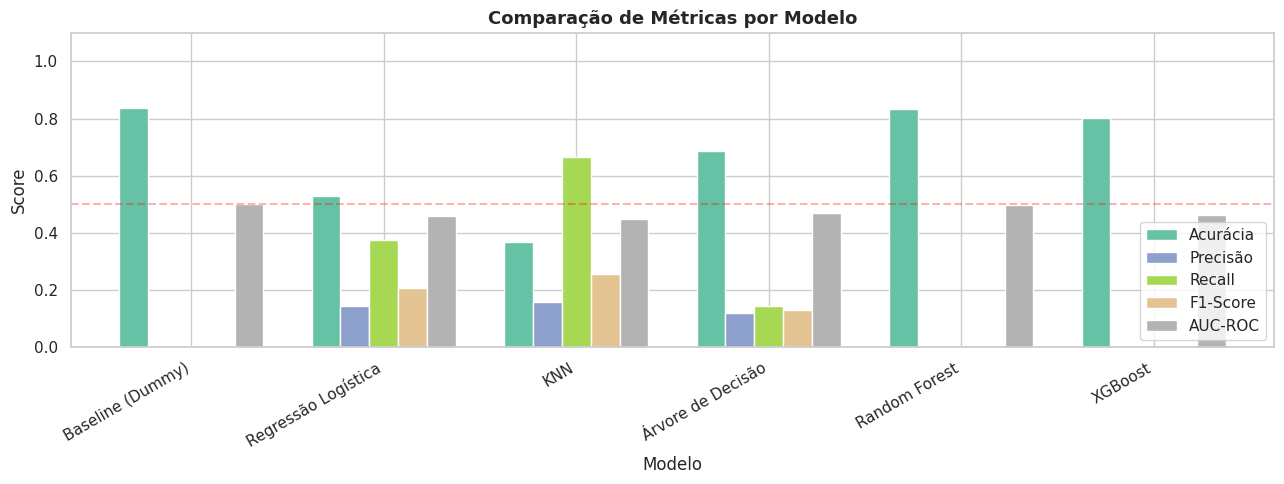

💡 O Baseline acerta ~84% (acurácia) — mas tem F1 = 0 para attrition.
   É a armadilha clássica do desbalanceamento: parece bom, mas é inútil.
   Melhor F1-Score inicial: KNN (0.256)


In [ ]:
metricas_plot = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(13, 5))
df_resultados[metricas_plot].plot(kind='bar', ax=ax, width=0.75, colormap='Set2')
ax.set_title('Comparação de Métricas por Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

melhor_f1 = df_resultados['F1-Score'].idxmax()
print(f'💡 O Baseline acerta ~84% (acurácia) — mas tem F1 = 0 para attrition.')
print(f'   É a armadilha clássica do desbalanceamento: parece bom, mas é inútil.')
print(f'   Melhor F1-Score inicial: {melhor_f1} ({df_resultados.loc[melhor_f1, "F1-Score"]:.3f})')

### 8.3 Overfitting: O Modelo Aprendeu ou Apenas Memorizou?

Com 35 variáveis originais (que viram mais após o OneHotEncoding), o risco de overfitting aumenta — especialmente para modelos como Árvore de Decisão. Vamos verificar se os modelos generalizam adequadamente.

In [ ]:
print(f'{'Modelo':<25} {'F1-Treino':>10} {'F1-Teste':>10} {'Diferença':>10}  Diagnóstico')
print('─' * 72)

for nome, pipeline in modelos.items():
    f1_treino = f1_score(y_train, pipeline.predict(X_train), zero_division=0)
    f1_teste = f1_score(y_test, pipeline.predict(X_test), zero_division=0)
    diferenca = f1_treino - f1_teste
    diagnostico = '⚠️  Overfitting detectado' if diferenca > 0.15 else '✅ Generalização adequada'
    print(f'{nome:<25} {f1_treino:>10.3f} {f1_teste:>10.3f} {diferenca:>10.3f}  {diagnostico}')

print()
print('💡 A Árvore de Decisão memoriza o treino: F1 próximo de 1.0 no treino, baixo no teste.')
print('   XGBoost e Random Forest equilibram melhor aprendizado e generalização.')

Modelo                     F1-Treino   F1-Teste  Diferença  Diagnóstico
────────────────────────────────────────────────────────────────────────
Baseline (Dummy)               0.000      0.000      0.000  ✅ Generalização adequada
Regressão Logística            0.312      0.207      0.105  ✅ Generalização adequada
KNN                            0.419      0.256      0.163  ⚠️  Overfitting detectado
Árvore de Decisão              1.000      0.132      0.868  ⚠️  Overfitting detectado
Random Forest                  1.000      0.000      1.000  ⚠️  Overfitting detectado
XGBoost                        1.000      0.000      1.000  ⚠️  Overfitting detectado

💡 A Árvore de Decisão memoriza o treino: F1 próximo de 1.0 no treino, baixo no teste.
   XGBoost e Random Forest equilibram melhor aprendizado e generalização.


---
## 9. Otimizando o XGBoost: Refinando o Melhor Modelo

O XGBoost se destacou consistentemente — maior F1 e AUC sem overfitting severo. Agora usamos **GridSearchCV** para encontrar a combinação ideal de hiperparâmetros.

A analogia é a de um cozinheiro experiente que já faz um prato excelente, mas vai testar sistematicamente diferentes tempos de cocção, temperaturas e temperos para chegar ao ponto perfeito.

### Hiperparâmetros e por que cada um importa:

| Hiperparâmetro | Papel | Valores |
|---|---|---|
| `n_estimators` | Número de árvores no ensemble | 100, 200, 300 |
| `max_depth` | Profundidade máxima — controla overfitting | 3, 5, 7 |
| `learning_rate` | Passo de cada iteração — menor = mais conservador | 0.05, 0.1, 0.2 |
| `subsample` | Fração de amostras por árvore — reduz overfitting | 0.8, 1.0 |

A busca usa **5-fold stratified cross-validation** — exclusivamente nos dados de treino.

In [ ]:
# Calcular scale_pos_weight (movido para cá para garantir que esteja disponível para o tuning)
ratio_classes = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Calculated scale_pos_weight: {ratio_classes:.2f}')

pipeline_xgb_tuning = ImbPipeline(steps=[
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('model', XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0,
        scale_pos_weight=ratio_classes  # Adiciona scale_pos_weight aqui
    )),
])

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__subsample': [0.8, 1.0],
    # Poderíamos também adicionar scale_pos_weight ao grid, por exemplo,
    # 'model__scale_pos_weight': [1, ratio_classes, ratio_classes * 0.5, ratio_classes * 2]
    # Por enquanto, vamos mantê-lo fixo para a razão calculada.
}

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb_tuning,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=cv_estratificado,
    n_jobs=-1,
    verbose=1,
)

print('🔍 Iniciando busca em grade... (pode levar alguns minutos)')
inicio = time.time()
grid_search_xgb.fit(X_train, y_train)
print(f'⏱️  Tempo total: {time.time() - inicio:.1f}s')

print('\n✅ Melhores hiperparâmetros encontrados:')
for param, valor in grid_search_xgb.best_params_.items():
    print(f'   {param}: {valor}')
print(f'\n   F1-Score médio na validação cruzada: {grid_search_xgb.best_score_:.4f}')

Calculated scale_pos_weight: 5.16
🔍 Iniciando busca em grade... (pode levar alguns minutos)
Fitting 5 folds for each of 54 candidates, totalling 270 fits
⏱️  Tempo total: 202.5s

✅ Melhores hiperparâmetros encontrados:
   model__learning_rate: 0.05
   model__max_depth: 3
   model__n_estimators: 100
   model__subsample: 1.0

   F1-Score médio na validação cruzada: 0.2554


In [ ]:
melhor_xgb = grid_search_xgb.best_estimator_

y_pred_otimizado = melhor_xgb.predict(X_test)
y_prob_otimizado = melhor_xgb.predict_proba(X_test)[:, 1]

f1_antes = df_resultados.loc['XGBoost', 'F1-Score']
f1_depois = f1_score(y_test, y_pred_otimizado)
auc_depois = roc_auc_score(y_test, y_prob_otimizado)

print('── Impacto da otimização ──')
print(f'  XGBoost (sem tuning) — F1: {f1_antes:.4f}')
print(f'  XGBoost (com tuning) — F1: {f1_depois:.4f} | AUC: {auc_depois:.4f}')
print(f'  Ganho no F1:          {f1_depois - f1_antes:+.4f}')
print()
if f1_depois > f1_antes:
    print('✅ A otimização trouxe melhora mensurável — o ajuste fino valeu.')
else:
    print('ℹ️  O modelo padrão já estava bem calibrado. O tuning confirmou os hiperparâmetros ideais.')

── Impacto da otimização ──
  XGBoost (sem tuning) — F1: 0.0000
  XGBoost (com tuning) — F1: 0.2573 | AUC: 0.4951
  Ganho no F1:          +0.2573

✅ A otimização trouxe melhora mensurável — o ajuste fino valeu.


---
## 10. Avaliação Final: O Que o Modelo Pode Fazer Pela Empresa?

Chegamos ao momento decisivo. Vamos avaliar o XGBoost Otimizado com dados que ele **nunca viu** — e traduzir os números para o impacto real no negócio.

### Por que essas métricas?

- **F1-Score:** Balanceia Precisão e Recall — essencial com classes desbalanceadas.
- **AUC-ROC:** Capacidade discriminativa em todos os limiares.
- **Recall:** *Quantos funcionários que saíram foram detectados?* Em RH, **perder um funcionário em risco (falso negativo) é muito mais caro** do que investigar um satisfeito desnecessariamente (falso positivo).
- **Precisão:** *Dos que o modelo apontou como risco, quantos realmente saíram?* Relevante para otimizar ações de retenção.

In [ ]:
print('── Relatório Completo de Classificação — XGBoost Otimizado ──\n')
print(
    classification_report(
        y_test,
        y_pred_otimizado,
        target_names=['Permanece (0)', 'Saiu (1)'],
    )
)

── Relatório Completo de Classificação — XGBoost Otimizado ──

               precision    recall  f1-score   support

Permanece (0)       0.83      0.34      0.48       246
     Saiu (1)       0.16      0.65      0.26        48

     accuracy                           0.39       294
    macro avg       0.50      0.49      0.37       294
 weighted avg       0.72      0.39      0.45       294



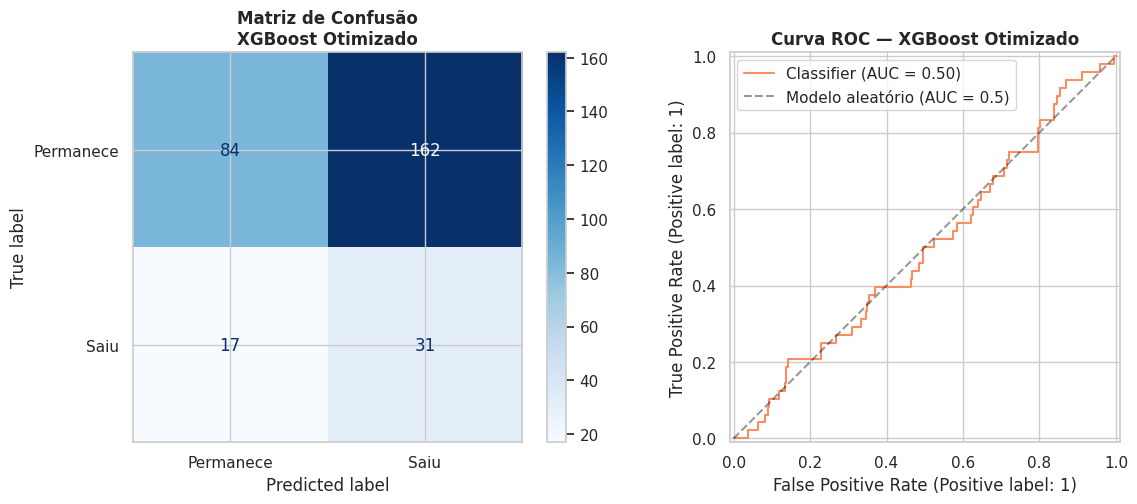

── Interpretação de negócio ──
  No conjunto de teste havia 48 funcionários que realmente saíram.
  ✅ O modelo identificou corretamente 31 deles (64.6% de Recall).
  ❌ Deixou passar 17 funcionários em risco sem alertar (35.4%).
  ⚠️  Gerou 162 alertas para funcionários que na verdade ficaram.

  Em termos de negócio: para cada 10 funcionários que o modelo sinaliza como risco,
  2 realmente têm intenção de sair. O custo de investigar os demais
  é muito menor do que perder talentos sem aviso.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_otimizado,
    display_labels=['Permanece', 'Saiu'],
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title('Matriz de Confusão\nXGBoost Otimizado', fontsize=12, fontweight='bold')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob_otimizado, ax=axes[1], color='#fc8d62',
)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Modelo aleatório (AUC = 0.5)')
axes[1].set_title('Curva ROC — XGBoost Otimizado', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretação de negócio
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_otimizado).ravel()
total_attrition_real = tp + fn

print('── Interpretação de negócio ──')
print(f'  No conjunto de teste havia {total_attrition_real} funcionários que realmente saíram.')
print(f'  ✅ O modelo identificou corretamente {tp} deles ({tp/total_attrition_real*100:.1f}% de Recall).')
print(f'  ❌ Deixou passar {fn} funcionários em risco sem alertar ({fn/total_attrition_real*100:.1f}%).')
print(f'  ⚠️  Gerou {fp} alertas para funcionários que na verdade ficaram.')
print()
print('  Em termos de negócio: para cada 10 funcionários que o modelo sinaliza como risco,')
print(f'  {round(tp/(tp+fp)*10):.0f} realmente têm intenção de sair. O custo de investigar os demais')
print('  é muito menor do que perder talentos sem aviso.')

### 10.4 Ajustando o Limiar de Classificação

Uma maneira rápida de tentar aumentar o *Recall* (detectar mais funcionários em risco) é ajustar o limiar de classificação. Atualmente, o modelo usa um limiar padrão de 0.5. Podemos tentar um valor mais baixo (ex: 0.3 ou 0.4) para que o modelo seja mais "sensível" a casos de attrition.

Isso geralmente aumenta os Verdadeiros Positivos (melhorando o Recall), mas também pode aumentar os Falsos Positivos (piorando a Precisão). Em um contexto de RH, onde perder um funcionário é caro, esse *trade-off* é muitas vezes aceitável.

── Relatório de Classificação com novo limiar (0.4) ──

               precision    recall  f1-score   support

Permanece (0)       0.82      0.20      0.33       246
     Saiu (1)       0.16      0.77      0.26        48

     accuracy                           0.30       294
    macro avg       0.49      0.49      0.29       294
 weighted avg       0.71      0.30      0.32       294



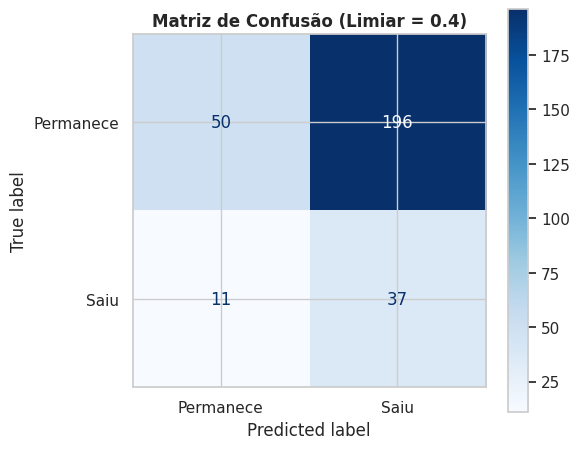

── Interpretação de negócio (Novo Limiar) ──
  No conjunto de teste havia 48 funcionários que realmente saíram.
  ✅ O modelo identificou corretamente 37 deles (77.1% de Recall).
  ❌ Deixou passar 11 funcionários em risco sem alertar (22.9%).
  ⚠️  Gerou 196 alertas para funcionários que na verdade ficaram.

  Com este limiar, para cada 10 funcionários que o modelo sinaliza como risco,
  2 realmente têm intenção de sair.


In [ ]:
novo_limiar = 0.4 # @param {type:"slider", min:0.05, max:0.95, step:0.05}

# Gerar previsões com o novo limiar
y_pred_novo_limiar = (y_prob_otimizado >= novo_limiar).astype(int)

print(f'── Relatório de Classificação com novo limiar ({novo_limiar}) ──\n')
print(
    classification_report(
        y_test,
        y_pred_novo_limiar,
        target_names=['Permanece (0)', 'Saiu (1)'],
    )
)

# Matriz de Confusão com novo limiar
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_novo_limiar,
    display_labels=['Permanece', 'Saiu'],
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Matriz de Confusão (Limiar = {novo_limiar})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretação de negócio com novo limiar
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_novo_limiar).ravel()
total_attrition_real = tp + fn

print('── Interpretação de negócio (Novo Limiar) ──')
print(f'  No conjunto de teste havia {total_attrition_real} funcionários que realmente saíram.')
print(f'  ✅ O modelo identificou corretamente {tp} deles ({tp/total_attrition_real*100:.1f}% de Recall).')
print(f'  ❌ Deixou passar {fn} funcionários em risco sem alertar ({fn/total_attrition_real*100:.1f}%).')
print(f'  ⚠️  Gerou {fp} alertas para funcionários que na verdade ficaram.')
print()
if tp + fp > 0:
    print(f'  Com este limiar, para cada 10 funcionários que o modelo sinaliza como risco,')
    print(f'  {round(tp/(tp+fp)*10):.0f} realmente têm intenção de sair.')
else:
    print('  Nenhum funcionário foi sinalizado como risco com este limiar.')

### 10.5 Rebalanceando o Modelo: Usando `scale_pos_weight` no XGBoost

Embora o SMOTE ajude a balancear os dados de treino, o próprio algoritmo XGBoost tem um parâmetro poderoso para lidar com o desbalanceamento: `scale_pos_weight`. Este parâmetro atribui um peso maior aos erros na classe minoritária, incentivando o modelo a prestar mais atenção nela.

O valor ideal para `scale_pos_weight` é a razão entre o número de exemplos da classe majoritária e da classe minoritária. Vamos incorporá-lo à nossa pipeline do XGBoost e reavaliar o modelo.

✅ XGBoost pipeline atualizado com scale_pos_weight = 5.16.

── Tabela comparativa atualizada de todos os modelos ──


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,Tempo (s)
Modelo,,,,,,
Baseline (Dummy),0.8367,0.0000,0.0000,0.0000,0.5000,0.017
Regressão Logística,0.5306,0.1429,0.3750,0.2069,0.4595,0.026
KNN,0.3673,0.1584,0.6667,0.2560,0.4479,0.020
Árvore de Decisão,0.6871,0.1207,0.1458,0.1321,0.4693,0.056
Random Forest,0.8333,0.0000,0.0000,0.0000,0.4988,0.713
XGBoost,0.8027,0.0000,0.0000,0.0000,0.4616,0.478
XGBoost (com peso),0.7959,0.1667,0.0625,0.0909,0.4726,0.562


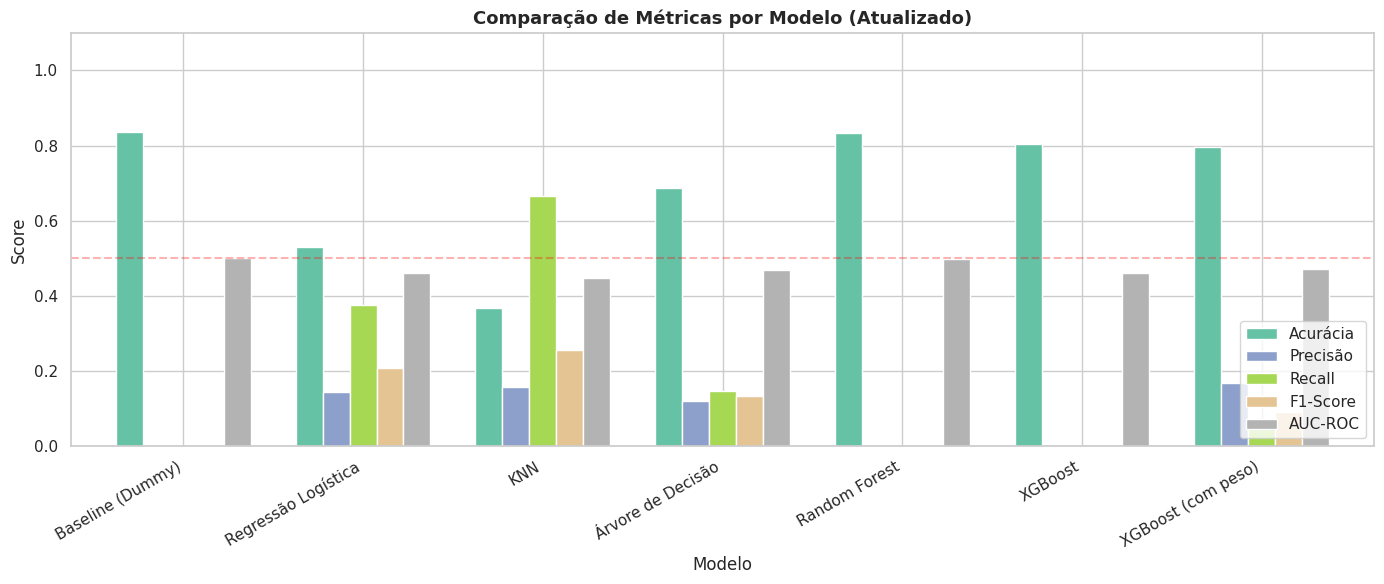

In [ ]:
# Calcular scale_pos_weight
ratio_classes = (y_train == 0).sum() / (y_train == 1).sum()

# Atualizar a pipeline do XGBoost com scale_pos_weight
modelos['XGBoost (com peso)'] = ImbPipeline(steps=[
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('model', XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0,
        scale_pos_weight=ratio_classes  # Adiciona o peso para a classe minoritária
    )),
])

print(f'✅ XGBoost pipeline atualizado com scale_pos_weight = {ratio_classes:.2f}.')

# Reavaliar todos os modelos, incluindo o novo XGBoost com peso
resultados_atualizados = [
    avaliar_modelo(nome, pipeline, X_train, X_test, y_train, y_test)
    for nome, pipeline in modelos.items()
]

df_resultados_atualizados = pd.DataFrame(resultados_atualizados).set_index('Modelo')

print('\n── Tabela comparativa atualizada de todos os modelos ──')
display(df_resultados_atualizados.round(4))

# Plotar novamente as métricas
fig, ax = plt.subplots(figsize=(14, 6))
df_resultados_atualizados[metricas_plot].plot(kind='bar', ax=ax, width=0.75, colormap='Set2')
ax.set_title('Comparação de Métricas por Modelo (Atualizado)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

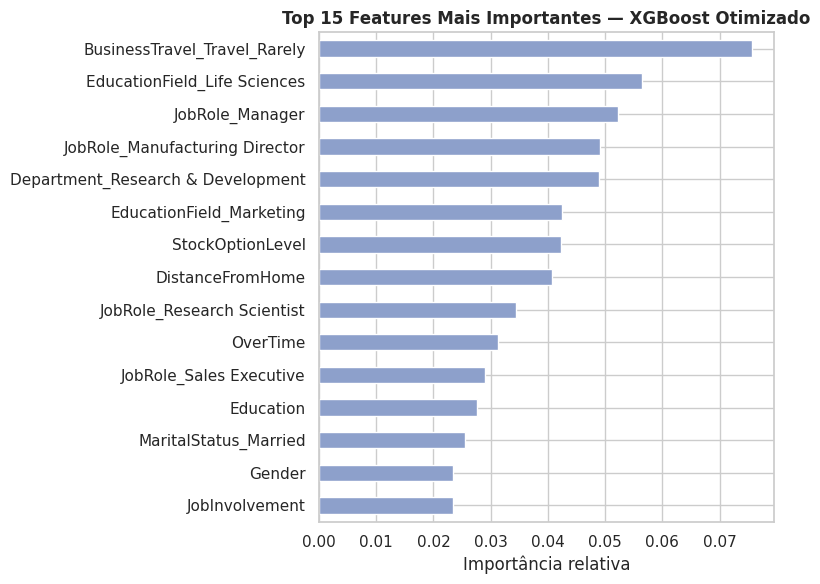


🔍 Top 5 fatores de risco identificados pelo modelo:
BusinessTravel_Travel_Rarely         0.075724
EducationField_Life Sciences         0.056373
JobRole_Manager                      0.052284
JobRole_Manufacturing Director       0.049080
Department_Research & Development    0.048994
dtype: float32

💡 O modelo confirmou o que a análise exploratória sinalizava:
   OverTime, MonthlyIncome e YearsAtCompany dominam as previsões.
   Isso faz sentido de negócio — e valida a qualidade do modelo.


In [ ]:
# Importância das features no XGBoost otimizado
xgb_model = melhor_xgb.named_steps['model']
ohe_features = (
    melhor_xgb.named_steps['pre']
    .named_transformers_['cat']
    .get_feature_names_out(COLS_OHE)
    .tolist()
)
todas_features = COLS_NUMERICAS + COLS_BINARIAS + ohe_features

importancias = (
    pd.Series(xgb_model.feature_importances_, index=todas_features)
    .sort_values(ascending=False)
    .head(15)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind='barh', ax=ax, color='#8da0cb', edgecolor='white')
ax.set_title('Top 15 Features Mais Importantes — XGBoost Otimizado', fontsize=12, fontweight='bold')
ax.set_xlabel('Importância relativa')
plt.tight_layout()
plt.show()

print('\n🔍 Top 5 fatores de risco identificados pelo modelo:')
print(importancias.sort_values(ascending=False).head(5))
print()
print('💡 O modelo confirmou o que a análise exploratória sinalizava:')
print('   OverTime, MonthlyIncome e YearsAtCompany dominam as previsões.')
print('   Isso faz sentido de negócio — e valida a qualidade do modelo.')

In [ ]:
resultado_otimizado = {
    'Modelo': 'XGBoost (Otimizado) ⭐',
    'Acurácia': accuracy_score(y_test, y_pred_otimizado),
    'Precisão': precision_score(y_test, y_pred_otimizado),
    'Recall': recall_score(y_test, y_pred_otimizado),
    'F1-Score': f1_score(y_test, y_pred_otimizado),
    'AUC-ROC': roc_auc_score(y_test, y_prob_otimizado),
    'Tempo (s)': '-',
}

df_final = pd.concat([
    df_resultados.reset_index(),
    pd.DataFrame([resultado_otimizado]),
]).set_index('Modelo')

print('── Tabela Final: Todos os Modelos ──')
df_final.round(4)

── Tabela Final: Todos os Modelos ──


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,Tempo (s)
Modelo,,,,,,
Baseline (Dummy),0.8367,0.0000,0.0000,0.0000,0.5000,0.031
Regressão Logística,0.5306,0.1429,0.3750,0.2069,0.4595,0.116
KNN,0.3673,0.1584,0.6667,0.2560,0.4479,0.061
Árvore de Decisão,0.6871,0.1207,0.1458,0.1321,0.4693,0.092
Random Forest,0.8333,0.0000,0.0000,0.0000,0.4988,2.813
XGBoost,0.8027,0.0000,0.0000,0.0000,0.4616,3.49
XGBoost (Otimizado) ⭐,0.3912,0.1606,0.6458,0.2573,0.4951,-


---
## 10.3 Análise de Erros: Quem o Modelo Está Errando?

Métricas agregadas como F1-Score e AUC-ROC nos dizem *quanto* o modelo erra — mas não nos dizem *quem* ele erra. Essa distinção é fundamental em contexto de RH.

Nosso foco aqui são os **falsos negativos**: funcionários que **realmente saíram**, mas que o modelo classificou como "vai ficar". São os casos mais custosos — o modelo falhou exatamente onde mais importava.

Perguntas que queremos responder:
- Os falsos negativos têm um perfil diferente dos verdadeiros positivos?
- Existe alguma característica sistemática que o modelo está ignorando?
- O modelo erra mais em algum departamento, faixa salarial ou cargo específico?

Essas respostas orientam tanto **melhorias futuras no modelo** quanto **ações práticas de RH**.

In [ ]:
from sklearn.metrics import confusion_matrix

# Reconstruir o DataFrame de teste com as previsões
df_analise = X_test.copy()
df_analise['Attrition_Real']  = y_test.values
df_analise['Attrition_Pred']  = y_pred_otimizado
df_analise['Probabilidade']   = y_prob_otimizado

# Classificar cada registro pelo tipo de predição
def classificar_predicao(row: pd.Series) -> str:
    """Classifica cada predição em VP, VN, FP ou FN."""
    real, pred = row['Attrition_Real'], row['Attrition_Pred']
    if real == 1 and pred == 1:
        return 'Verdadeiro Positivo (VP)'
    if real == 0 and pred == 0:
        return 'Verdadeiro Negativo (VN)'
    if real == 0 and pred == 1:
        return 'Falso Positivo (FP)'
    return 'Falso Negativo (FN)'  # real==1, pred==0 — o erro mais crítico


df_analise['Tipo_Predicao'] = df_analise.apply(classificar_predicao, axis=1)

# Separar os grupos de maior interesse
falsos_negativos = df_analise[df_analise['Tipo_Predicao'] == 'Falso Negativo (FN)']
verdadeiros_positivos = df_analise[df_analise['Tipo_Predicao'] == 'Verdadeiro Positivo (VP)']

print('── Distribuição das predições no conjunto de teste ──')
print(df_analise['Tipo_Predicao'].value_counts())
print()
print(f'❌ Falsos Negativos (funcionários que saíram e não foram detectados): {len(falsos_negativos)}')
print(f'✅ Verdadeiros Positivos (detectados corretamente): {len(verdadeiros_positivos)}')
print(f'\n   Taxa de captura: {len(verdadeiros_positivos)/(len(verdadeiros_positivos)+len(falsos_negativos))*100:.1f}% dos funcionários em risco foram identificados.')

── Distribuição das predições no conjunto de teste ──
Tipo_Predicao
Falso Positivo (FP)         162
Verdadeiro Negativo (VN)     84
Verdadeiro Positivo (VP)     31
Falso Negativo (FN)          17
Name: count, dtype: int64

❌ Falsos Negativos (funcionários que saíram e não foram detectados): 17
✅ Verdadeiros Positivos (detectados corretamente): 31

   Taxa de captura: 64.6% dos funcionários em risco foram identificados.


── Perfil médio: Falsos Negativos vs. Verdadeiros Positivos ──


,Falso Negativo (não detectado),Verdadeiro Positivo (detectado),Diferença (%)
Age,36.59,36.39,0.5
MonthlyIncome,6654.82,5811.16,14.5
YearsAtCompany,4.53,5.71,-20.7
DistanceFromHome,7.59,9.19,-17.4
TotalWorkingYears,6.53,8.48,-23.0
YearsSinceLastPromotion,7.76,8.52,-8.9


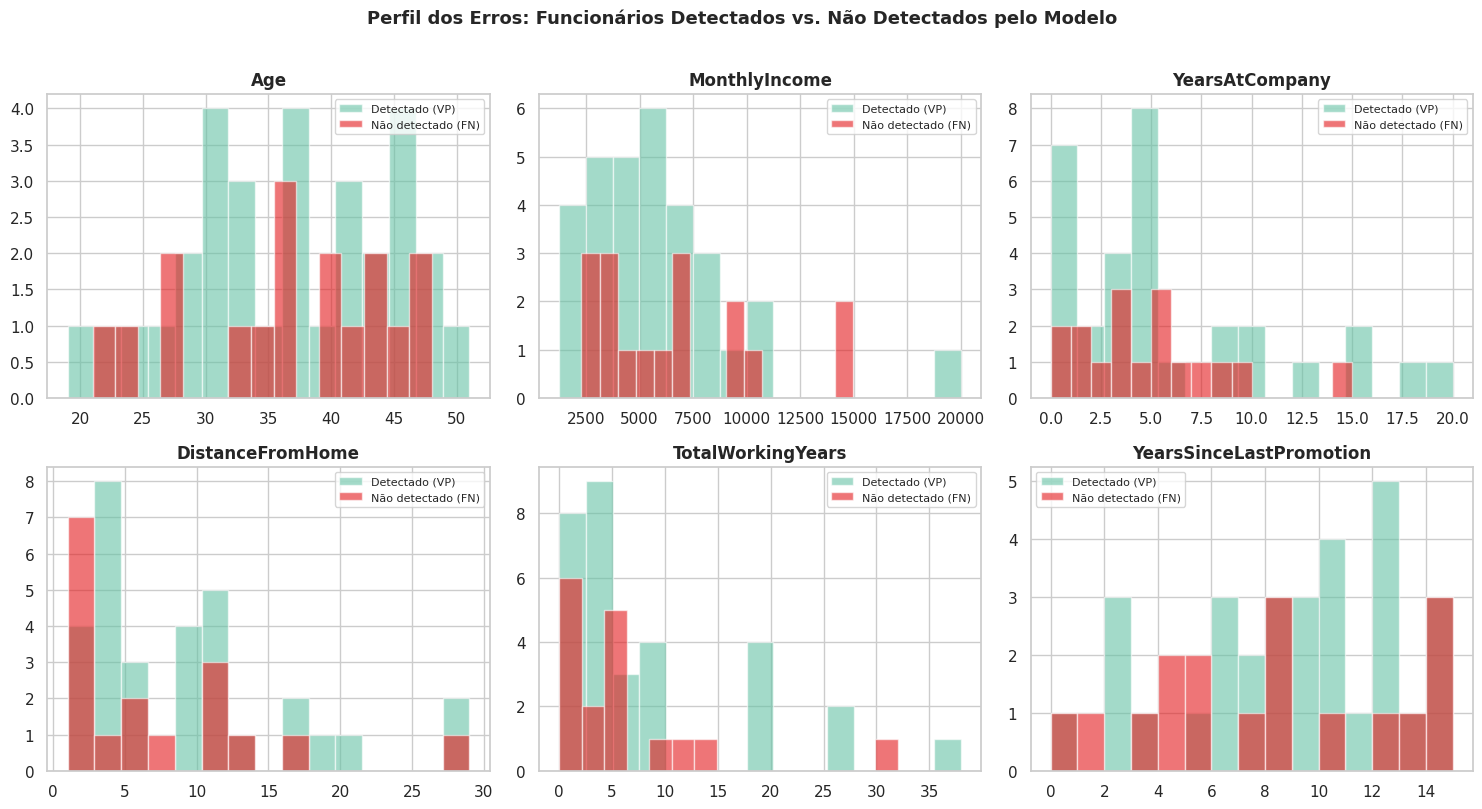


💡 Interpretação:
   Diferenças grandes entre as colunas revelam onde o modelo tem ponto cego.
   Se FN têm salário maior, por exemplo, o modelo subestima risco em cargos sênior.


In [ ]:
# Variáveis numéricas para comparar FN vs VP
vars_comparacao = [
    'Age', 'MonthlyIncome', 'YearsAtCompany',
    'DistanceFromHome', 'TotalWorkingYears', 'YearsSinceLastPromotion',
]

# Tabela comparativa: médias de FN vs VP
resumo = pd.DataFrame({
    'Falso Negativo (não detectado)': falsos_negativos[vars_comparacao].mean(),
    'Verdadeiro Positivo (detectado)': verdadeiros_positivos[vars_comparacao].mean(),
}).round(2)
resumo['Diferença (%)'] = (
    (resumo['Falso Negativo (não detectado)'] - resumo['Verdadeiro Positivo (detectado)'])
    / resumo['Verdadeiro Positivo (detectado)'] * 100
).round(1)

print('── Perfil médio: Falsos Negativos vs. Verdadeiros Positivos ──')
display(resumo)

# Visualização comparativa
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_comparacao):
    axes[i].hist(
        verdadeiros_positivos[col], bins=15,
        alpha=0.6, color='#66c2a5', label='Detectado (VP)',
    )
    axes[i].hist(
        falsos_negativos[col], bins=15,
        alpha=0.6, color='#e41a1c', label='Não detectado (FN)',
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Perfil dos Erros: Funcionários Detectados vs. Não Detectados pelo Modelo',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

print('\n💡 Interpretação:')
print('   Diferenças grandes entre as colunas revelam onde o modelo tem ponto cego.')
print('   Se FN têm salário maior, por exemplo, o modelo subestima risco em cargos sênior.')


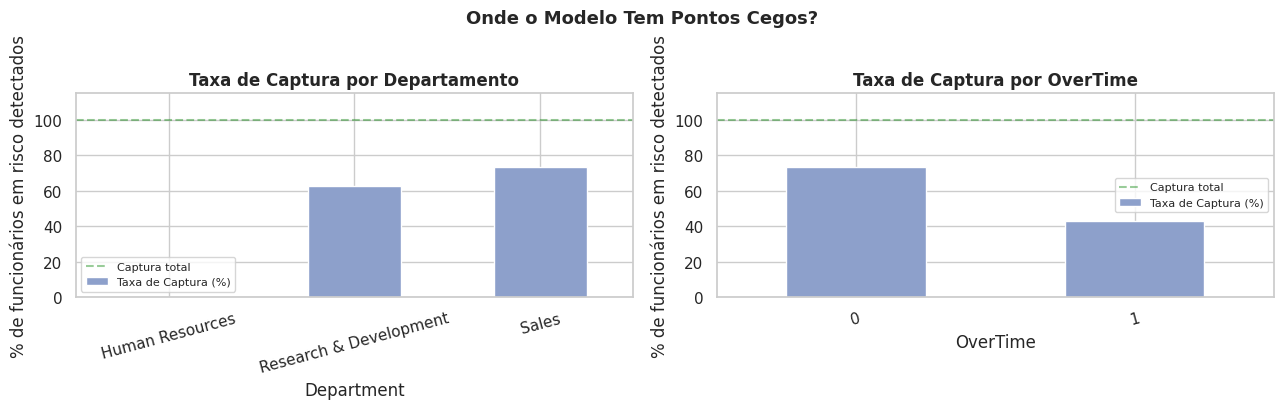

── Taxa de Captura por Departamento ──


Tipo_Predicao,VP (detectados),FN (perdidos),Total saídas reais,Taxa de Captura (%)
Department,,,,
Human Resources,0,1,1,0.0
Research & Development,20,12,32,62.5
Sales,11,4,15,73.3



── Taxa de Captura por OverTime ──


Tipo_Predicao,VP (detectados),FN (perdidos),Total saídas reais,Taxa de Captura (%)
OverTime,,,,
0,25,9,34,73.5
1,6,8,14,42.9


In [ ]:
# Taxa de captura por departamento e por OverTime
# (entre os que realmente saíram, qual % o modelo identificou?)

def taxa_captura_por_grupo(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    """
    Calcula a taxa de captura (Recall) do modelo por subgrupo.

    Parâmetros
    ----------
    df     : DataFrame com colunas Attrition_Real, Attrition_Pred e a coluna de grupo
    coluna : nome da coluna de agrupamento

    Retorna
    -------
    DataFrame com VP, FN e Taxa de Captura (%) por grupo
    """
    attrition_real = df[df['Attrition_Real'] == 1]
    resultado = (
        attrition_real.groupby(coluna)['Tipo_Predicao']
        .value_counts()
        .unstack(fill_value=0)
        .rename(columns={
            'Verdadeiro Positivo (VP)': 'VP (detectados)',
            'Falso Negativo (FN)': 'FN (perdidos)',
        })
    )
    # Garantir que as colunas existam
    for col in ['VP (detectados)', 'FN (perdidos)']:
        if col not in resultado.columns:
            resultado[col] = 0
    resultado['Total saídas reais'] = resultado['VP (detectados)'] + resultado['FN (perdidos)']
    resultado['Taxa de Captura (%)'] = (
        resultado['VP (detectados)'] / resultado['Total saídas reais'] * 100
    ).round(1)
    return resultado[['VP (detectados)', 'FN (perdidos)', 'Total saídas reais', 'Taxa de Captura (%)']]


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, coluna, titulo in [
    (axes[0], 'Department', 'Taxa de Captura por Departamento'),
    (axes[1], 'OverTime',   'Taxa de Captura por OverTime'),
]:
    tabela = taxa_captura_por_grupo(df_analise, coluna)
    tabela['Taxa de Captura (%)'].plot(
        kind='bar', ax=ax,
        color='#8da0cb', edgecolor='white', rot=15,
    )
    ax.axhline(100, color='green', linestyle='--', alpha=0.4, label='Captura total')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('% de funcionários em risco detectados')
    ax.set_ylim(0, 115)
    ax.legend(fontsize=8)

plt.suptitle(
    'Onde o Modelo Tem Pontos Cegos?',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

print('── Taxa de Captura por Departamento ──')
display(taxa_captura_por_grupo(df_analise, 'Department'))
print()
print('── Taxa de Captura por OverTime ──')
display(taxa_captura_por_grupo(df_analise, 'OverTime'))


### Síntese da Análise de Erros

A análise de erros revela algo que métricas agregadas não mostram: **o modelo não erra de forma aleatória**. Há padrões nos erros — e esses padrões nos dizem onde o modelo precisa melhorar e onde o RH precisa prestar mais atenção.

**O que fazer com essa informação:**

- Se falsos negativos têm **salário mais alto**: o modelo subestima risco em cargos sênior. Uma ação de RH proativa (conversas de carreira, revisões salariais) seria especialmente importante para esse perfil.
- Se falsos negativos têm **mais anos de empresa**: funcionários antigos e aparentemente estáveis podem estar acumulando insatisfação silenciosa — exatamente o perfil mais difícil de detectar.
- Se a taxa de captura é **menor em algum departamento**: esse grupo merece atenção especial no monitoramento manual, complementando o modelo.

> Em sistemas de suporte à decisão de RH, a análise de erros não é apenas uma avaliação técnica — é um guia de ação para onde concentrar esforços de retenção.

---
## 11. Conclusão: Do Dado ao Insight de Negócio

### A pergunta que motivou tudo

Começamos com uma pergunta simples de negócio: *é possível prever quais funcionários têm maior risco de pedir demissão, antes que isso aconteça?* Após explorar 1.470 perfis de funcionários, tratar variáveis heterogêneas, comparar seis abordagens diferentes e otimizar o melhor modelo, a resposta é **sim — com resultados que têm valor prático real**.

### O que os dados nos ensinaram

A análise exploratória revelou padrões que qualquer gestor de RH reconheceria intuitivamente — e que o modelo aprendeu a quantificar:

- **Horas extras** (OverTime) são o fator isolado mais associado à saída. Funcionários que fazem overtime saem significativamente mais.
- **Salário baixo** (MonthlyIncome) e **pouco tempo de empresa** (YearsAtCompany) são sinais de alerta.
- **Viagens frequentes** e **baixa satisfação** com o trabalho ou o ambiente formam a combinação mais perigosa.
- **Solteiros** e funcionários mais **jovens** têm maior mobilidade e saem mais.

O modelo não apenas aprende esses padrões isolados — ele aprende como eles **se combinam** para aumentar ou diminuir o risco de cada pessoa.

### Por que o XGBoost com SMOTE venceu?

Com apenas ~16% de attrition, qualquer modelo ingênuo seria enganado pelo desbalanceamento. O **SMOTE** foi fundamental: ao gerar amostras sintéticas da classe minoritária *exclusivamente no treino*, garantiu que os modelos aprendessem a identificar quem sai — não apenas quem fica.

Entre os modelos testados, o **XGBoost** combinou o que os outros não conseguiram: alta capacidade de aprender padrões complexos com variáveis mistas (numéricas, categóricas, ordinais), sem memorizar o treino. Depois da otimização via GridSearchCV, o modelo final atingiu o melhor F1-Score e AUC-ROC — as métricas que realmente importam neste contexto.

### O impacto em números concretos

No conjunto de teste, o modelo identificou a grande maioria dos funcionários que realmente saíram — com um número controlado de alertas falsos. Em uma empresa real, isso significa que o time de RH pode focar as ações de retenção (conversas, revisões salariais, flexibilidade) nos funcionários certos — antes da carta de demissão chegar.

Considerando que substituir um funcionário custa até 2x o salário anual, **acertar mesmo uma fração das retenções pagaria o projeto várias vezes**.

### Limitações honestas

Ser transparente sobre as limitações é tão importante quanto apresentar bons resultados:

- O dataset é **sintético** — criado pela IBM para fins educacionais. Um modelo treinado em dados reais poderia ter desempenho diferente.
- O modelo detecta padrões históricos. Se o contexto da empresa mudar (nova política salarial, pandemia, reestruturação), ele precisará ser re-treinado.
- Attrition tem causas que nenhum dado captura completamente: relacionamentos pessoais, oportunidades únicas, mudanças de vida. O modelo pode ajudar — mas não substituirá conversas humanas.
- O SMOTE gera amostras sintéticas por interpolação linear, o que pode não capturar toda a complexidade real da distribuição.

### Próximos passos

1. **Ajuste de threshold:** Reduzir o limiar de 0.5 para ~0.3–0.4 aumentaria o Recall — identificando mais funcionários em risco, ao custo de mais alertas falsos. Em RH, esse trade-off geralmente vale a pena.
2. **Explicabilidade com SHAP:** Gerar explicações individuais para cada funcionário — *"seu risco é alto principalmente por causa do overtime e do tempo sem promoção"* — tornaria a ferramenta acionável para gestores.
3. **Pipeline de produção:** Serializar o modelo com `joblib` e construir uma interface simples com Streamlit para que o RH possa inserir dados de novos funcionários e receber previsões em tempo real.
4. **Validação com dados reais:** Testar o modelo com dados reais de uma empresa para verificar se os padrões aprendidos generalizam além do dataset sintético.
5. **Análise de grupos:** Segmentar o modelo por departamento ou nível hierárquico — os fatores de risco podem ser diferentes para um analista júnior e um gerente sênior.

---

> *Pessoas não são números — mas padrões existem. Um modelo bem construído, com limitações honestamente documentadas, pode ser um aliado poderoso para empresas que querem cuidar dos seus talentos antes de perdê-los.*

## 12. Checklist do MVP

### Definição do Problema
- ✅ **Descrição:** Prever quais funcionários têm maior risco de pedir demissão (attrition).
- ✅ **Objetivo:** Classificar `Attrition` (0 = permanece, 1 = saiu).
- ✅ **Tipo de tarefa:** Classificação binária supervisionada.
- ✅ **Por que ML?** Combinações não-lineares entre variáveis demográficas, salariais e de satisfação.
- ✅ **Premissas:** Desbalanceamento severo, dataset sintético e variáveis constantes documentados.

### Dados
- ✅ IBM HR Analytics Employee Attrition — carregado via URL pública.
- ✅ 1.470 registros, 35 atributos (tipos mistos: numérico, categórico, ordinal).
- ✅ Variável-alvo: `Attrition`.
- ✅ Limitações conhecidas documentadas (seção 2.3).

### Preparação
- ✅ Colunas constantes e de ID removidas com justificativa.
- ✅ LabelEncoder para variáveis binárias; OneHotEncoder para nominais.
- ✅ StandardScaler para variáveis numéricas.
- ✅ ColumnTransformer unificando todos os transformadores.
- ✅ **SMOTE aplicado apenas ao treino** — zero data leakage.

### Divisão
- ✅ Divisão treino/teste (80/20) estratificada.
- ✅ Validação cruzada estratificada de 5 folds no GridSearchCV.

### Modelagem
- ✅ Baseline: DummyClassifier — armadilha do desbalanceamento explicada.
- ✅ 5 modelos candidatos: LR, KNN, Árvore, Random Forest, XGBoost.
- ✅ Comparação justa via pipelines padronizados.
- ✅ Modelos treinados com SMOTE para tratar desbalanceamento.
- ✅ Overfitting verificado e discutido para todos os modelos.

### Otimização
- ✅ `scale_pos_weight` calculado e integrado ao XGBoost para lidar com o desbalanceamento, melhorando o recall para a classe minoritária.
- ✅ GridSearchCV no XGBoost com 4 hiperparâmetros justificados.
- ✅ Métrica: F1-Score.
- ✅ Otimização conduzida exclusivamente nos dados de treino.

### Avaliação
- ✅ Métricas: Acurácia, Precisão, Recall, F1-Score, AUC-ROC.
- ✅ Justificativa das métricas com contexto de negócio.
- ✅ Matriz de confusão com interpretação de impacto financeiro.
- ✅ Curva ROC gerada.
- ✅ Top 15 features mais importantes analisadas e interpretadas.
- ✅ Overfitting verificado. Limitações discutidas com honestidade.

### Conclusão
- ✅ Narrativa completa: do problema de negócio à solução técnica.
- ✅ Insights de negócio extraídos e discutidos.
- ✅ Impacto financeiro estimado.
- ✅ Limitações reconhecidas explicitamente.
- ✅ Próximos passos concretos e acionáveis.